In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (2).csv


In [22]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [23]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [25]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [26]:
processing_df = df.copy()

In [27]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Remove CustomerID
processing_df.drop('CustomerID', axis=1, inplace=True)

# Convert Gender into numbers
le = LabelEncoder()
processing_df['Gender'] = le.fit_transform(processing_df['Gender'])

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(processing_df)

print("Preprocessing Completed!")

Preprocessing Completed!


In [28]:
!pip install scikit-learn-extra

In [29]:
from sklearn_extra.cluster import KMedoids

# Create K-Medoids model
kmedoids = KMedoids(n_clusters=3, random_state=42)

# Fit model
processing_df['Cluster'] = kmedoids.fit_predict(scaled_data)

# View first few rows
processing_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,1
1,1,21,15,81,2
2,0,20,16,6,1
3,0,23,16,77,2
4,0,31,17,40,1


In [30]:
from sklearn_extra.cluster import KMedoids

kmedoids = KMedoids(n_clusters=3, random_state=42)

processing_df['Cluster'] = kmedoids.fit_predict(scaled_data)

print(processing_df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   19                  15                      39        1
1       1   21                  15                      81        2
2       0   20                  16                       6        1
3       0   23                  16                      77        2
4       0   31                  17                      40        1


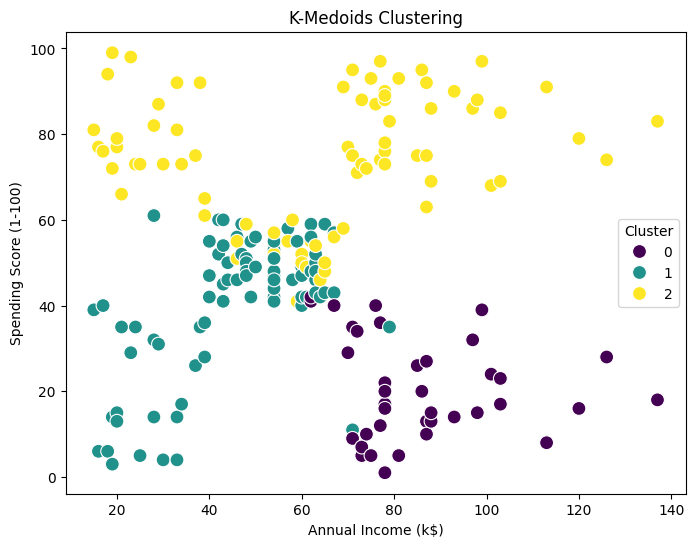

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=processing_df['Cluster'],
    palette='viridis',
    s=100
)

plt.title("K-Medoids Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [32]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)

processing_df['Hierarchical_Cluster'] = hc.fit_predict(scaled_data)

print(processing_df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster  \
0       1   19                  15                      39        1   
1       1   21                  15                      81        2   
2       0   20                  16                       6        1   
3       0   23                  16                      77        2   
4       0   31                  17                      40        1   

   Hierarchical_Cluster  
0                     0  
1                     0  
2                     1  
3                     0  
4                     1  


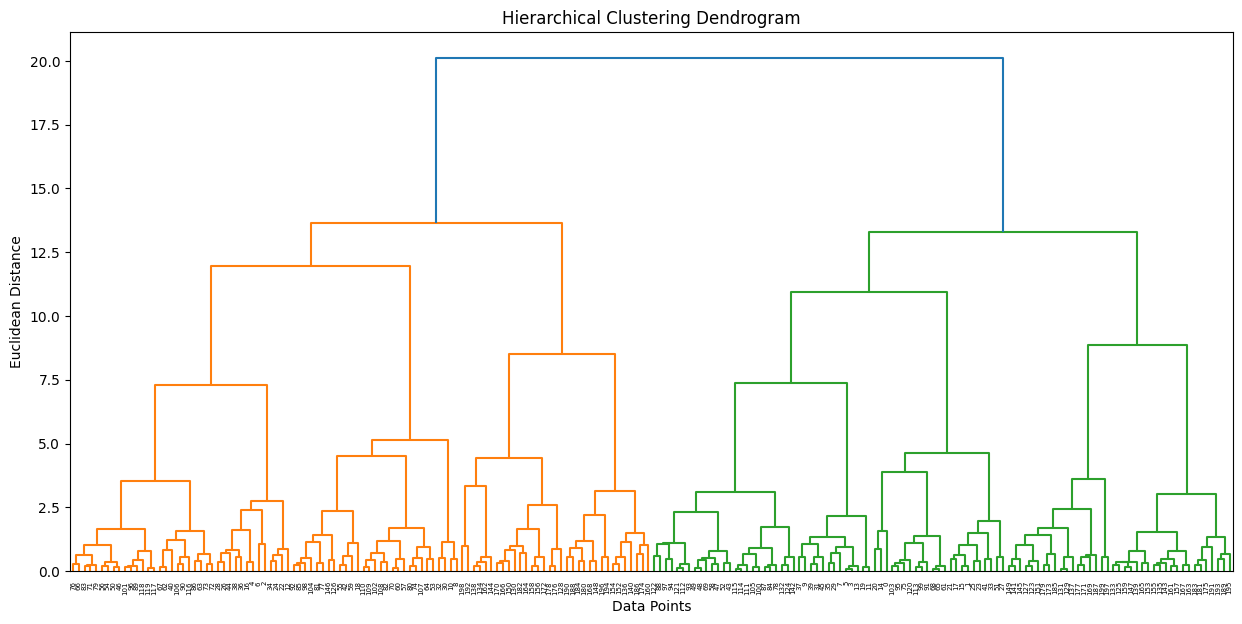

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns

linked_data = linkage(scaled_data, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

In [34]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)

processing_df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

print(processing_df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster  \
0       1   19                  15                      39        1   
1       1   21                  15                      81        2   
2       0   20                  16                       6        1   
3       0   23                  16                      77        2   
4       0   31                  17                      40        1   

   Hierarchical_Cluster  DBSCAN_Cluster  
0                     0              -1  
1                     0               0  
2                     1              -1  
3                     0               1  
4                     1               1  


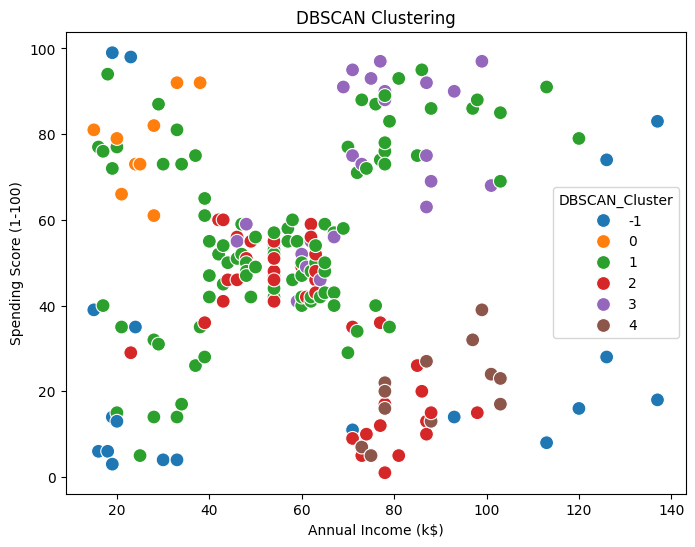

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=processing_df['DBSCAN_Cluster'],
    palette='tab10',
    s=100
)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()